# Maximum Explainable Variance (MEV)

This notebook reproduces the MEV experiment from the paper.

The objective is to determine whether the contextual representations of a word can be summarized by a single dominant direction in embedding space.

For each layer, PCA is applied to the contextual embeddings of a target word. The explained variance ratio of the first principal component is used as the Maximum Explainable Variance (MEV).

High MEV indicates that contextual representations remain similar and can be approximated by a static representation.

Low MEV indicates that contextual representations are highly context-dependent.

cell 1 - imports

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

cell 2 - Dataset

In [2]:
financial_bank = [
    "The bank approved the loan.",
    "The bank lowered interest rates.",
    "The bank opened a new branch.",
    "The bank rejected the application.",
    "The bank increased mortgage offerings."
]

cell 3 - extract Embeddings

In [3]:
sys.path.append("..") # add the parent directory to the system path to access the src folder
from src.embeddings import get_word_embedding


all_embeddings = []

for sentence in financial_bank:

    embeddings = get_word_embedding(
        sentence,
        "bank"
    )

    all_embeddings.append(
        embeddings
    )

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The bank approved the loan.
Position: 2
Token: bank

The bank lowered interest rates.
Position: 2
Token: bank

The bank opened a new branch.
Position: 2
Token: bank

The bank rejected the application.
Position: 2
Token: bank

The bank increased mortgage offerings.
Position: 2
Token: bank



cell 4 - compute MEV

PCA tries to find the direction that captures the most variation in the data.

In [4]:
def compute_mev(vectors):
    pca = PCA(n_components=1)
    pca.fit(vectors)
    return pca.explained_variance_ratio_[0]

cell 5 - Compute Layer-wise MEV

In [5]:
layer_mev = []

num_layers = len(
    all_embeddings[0]
)

for layer_idx in range(
    num_layers
):

    layer_vectors = []

    for sentence_idx in range(
        len(all_embeddings)
    ):

        layer_vectors.append(
            all_embeddings[sentence_idx][layer_idx]
        )

    layer_vectors = np.array(
        layer_vectors
    )  # convert to numpy array for PCA
    # shape: (num_sentences, embedding_dim)

    mev = compute_mev(
        layer_vectors
    )

    layer_mev.append(
        mev
    )

cell 6 - Inspect values

In [6]:
for layer, score in enumerate(
    layer_mev
):
    print(
        f"Layer {layer}: {score:.4f}"
    )

Layer 0: 1.0000
Layer 1: 0.3609
Layer 2: 0.3897
Layer 3: 0.3708
Layer 4: 0.3694
Layer 5: 0.3852
Layer 6: 0.3946
Layer 7: 0.4054
Layer 8: 0.4662
Layer 9: 0.4377
Layer 10: 0.4244
Layer 11: 0.3968
Layer 12: 0.3626


cell 7 - Plot

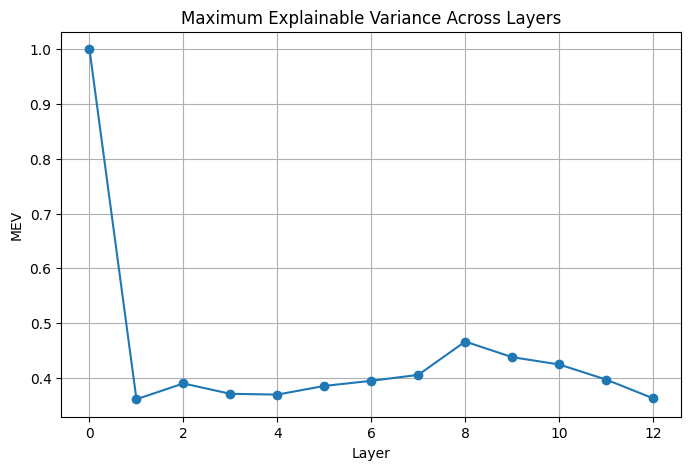

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(num_layers),
    layer_mev,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("MEV")

plt.title(
    "Maximum Explainable Variance Across Layers"
)

plt.grid(True)

plt.show()

## Interpretation

The MEV drops sharply after the embedding layer, indicating that contextual representations cannot be well summarized by a single static direction.

Although contextual embeddings remain relatively similar across financial contexts, their variation is distributed across multiple dimensions of the representation space.

This suggests that contextual information is encoded in a richer geometric structure than can be captured by a single prototype vector.

cell 1 -reusable function

In [8]:
def run_mev_experiment(
    sentences,
    target_word
):

    all_embeddings = []

    for sentence in sentences:

        embeddings = get_word_embedding(
            sentence,
            target_word
        )

        all_embeddings.append(
            embeddings
        )

    layer_mev = []

    num_layers = len(
        all_embeddings[0]
    )

    for layer_idx in range(
        num_layers
    ):

        layer_vectors = []

        for sentence_idx in range(
            len(all_embeddings)
        ):

            layer_vectors.append(
                all_embeddings[sentence_idx][layer_idx]
            )

        layer_vectors = np.array(
            layer_vectors
        )

        mev = compute_mev(
            layer_vectors
        )

        layer_mev.append(
            mev
        )

    return layer_mev

cell 2 - datasets definition

In [9]:
financial_bank = [
    "The bank approved the loan.",
    "The bank lowered interest rates.",
    "The bank opened a new branch.",
    "The bank rejected the application.",
    "The bank increased mortgage offerings."
]

mixed_bank = [
    "The bank approved the loan.",
    "The bank lowered interest rates.",
    "The fisherman sat on the bank of the river.",
    "The flood damaged the bank.",
    "Children played near the river bank."
]

cell 3 - run experiments

In [10]:
financial_mev = run_mev_experiment(
    financial_bank,
    "bank"
)

mixed_mev = run_mev_experiment(
    mixed_bank,
    "bank"
)

The bank approved the loan.
Position: 2
Token: bank

The bank lowered interest rates.
Position: 2
Token: bank

The bank opened a new branch.
Position: 2
Token: bank

The bank rejected the application.
Position: 2
Token: bank

The bank increased mortgage offerings.
Position: 2
Token: bank

The bank approved the loan.
Position: 2
Token: bank

The bank lowered interest rates.
Position: 2
Token: bank

The fisherman sat on the bank of the river.
Position: 6
Token: bank

The flood damaged the bank.
Position: 5
Token: bank

Children played near the river bank.
Position: 6
Token: bank



cell 4 - compare numerically

In [11]:
print(
    "Financial final layer:",
    financial_mev[-1]
)

print(
    "Mixed final layer:",
    mixed_mev[-1]
)

print(
    "Difference:",
    financial_mev[-1] - mixed_mev[-1]
)

Financial final layer: 0.36260155
Mixed final layer: 0.5925855
Difference: -0.22998396


cell 5 - plot both curves

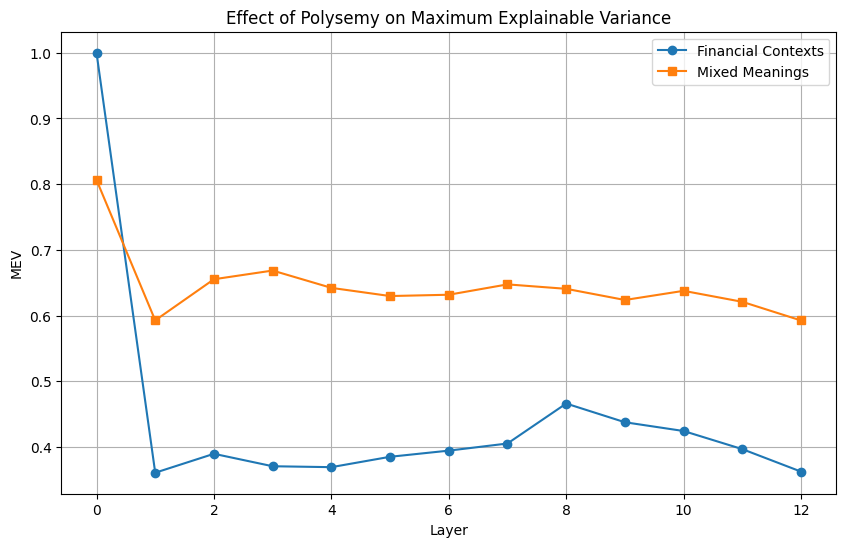

In [12]:
plt.figure(figsize=(10,6))

plt.plot(
    financial_mev,
    marker="o",
    label="Financial Contexts"
)

plt.plot(
    mixed_mev,
    marker="s",
    label="Mixed Meanings"
)

plt.xlabel("Layer")
plt.ylabel("MEV")

plt.title(
    "Effect of Polysemy on Maximum Explainable Variance"
)

plt.legend()

plt.grid(True)

plt.show()